# Part III: Tweet Sentiment Analysis with RNN, LSTM, and Word2Vec

This Google Drive version follows the PDF requirements. It mounts Google Drive and loads the instructor-assigned tweet CSV from Drive. Update DATA_PATH, TEXT_COLUMN, and LABEL_COLUMN after checking your CSV.

In [1]:
# Colab setup. Restart runtime if gensim/numpy compatibility requires it.
# !pip install contractions nltk gensim wordcloud gradio

import re, time, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from google.colab import drive

drive.mount('/content/drive')

try:
    import contractions
except ImportError:
    contractions = None

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Update this to the CSV file in your Google Drive.
DATA_PATH = '/content/drive/MyDrive/AI/7. Racist Sexist or Not Dataset/train_racisit.csv'
TEXT_COLUMN = 'tweet'
LABEL_COLUMN = 'label'

print('Dataset path:', DATA_PATH)
print('Exists:', pathlib.Path(DATA_PATH).exists())

Mounted at /content/drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Dataset path: /content/drive/MyDrive/AI/7. Racist Sexist or Not Dataset/train_racisit.csv
Exists: True


(31962, 3)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Columns: ['id', 'label', 'tweet']
label
0    29720
1     2242
Name: count, dtype: int64


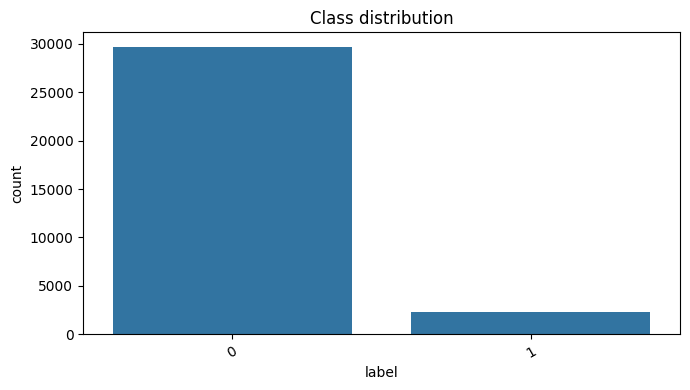

In [2]:
# Load assigned dataset from Google Drive.
if not pathlib.Path(DATA_PATH).exists():
    raise FileNotFoundError(
        'CSV not found. Upload the tweet dataset to Google Drive and update DATA_PATH. '
    )

df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())
print('Columns:', list(df.columns))
print(df[LABEL_COLUMN].value_counts())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=LABEL_COLUMN)
plt.title('Class distribution')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [3]:
# Text cleaning: lowercase, contractions, URLs, mentions, hashtags, numbers, special characters, stopwords, lemmatization.
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    if contractions is not None:
        text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()
df['clean_text'] = df[TEXT_COLUMN].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
display(df[[TEXT_COLUMN, 'clean_text', LABEL_COLUMN]].head())

,tweet,clean_text,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit use cause offer wheelchair ...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love take time ur,0
4,factsguide: society now #motivation,factsguide society motivation,0


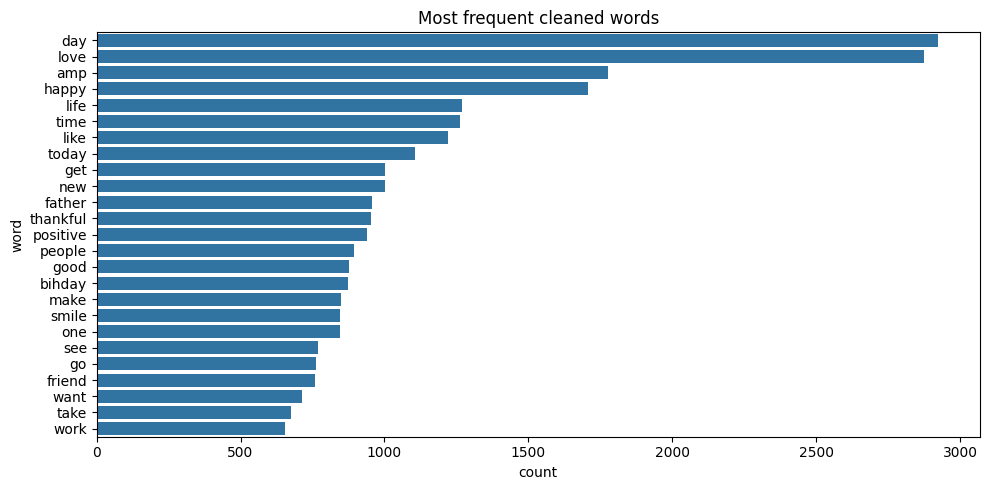

In [4]:
# Frequent-word visualization.
from collections import Counter
all_words = ' '.join(df['clean_text']).split()
freq = pd.DataFrame(Counter(all_words).most_common(25), columns=['word', 'count'])
plt.figure(figsize=(10, 5))
sns.barplot(data=freq, y='word', x='count')
plt.title('Most frequent cleaned words')
plt.tight_layout()
plt.show()

In [5]:
# Train/test split, tokenization, and percentile-based padding.
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(df[LABEL_COLUMN])
num_classes = len(label_encoder.classes_)
y = keras.utils.to_categorical(y_int, num_classes=num_classes) if num_classes > 2 else y_int

X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], y, test_size=0.2, random_state=SEED, stratify=y_int)

MAX_WORDS = 20000
EMBED_DIM = 100
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)
lengths = [len(s) for s in train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
MAX_LEN = max(MAX_LEN, 5)
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post', truncating='post')
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print('Classes:', label_encoder.classes_)
print('Vocab size:', vocab_size, 'Max length:', MAX_LEN)

Classes: [0 1]
Vocab size: 20000 Max length: 13


In [6]:
def compile_model(model):
    loss = 'binary_crossentropy' if num_classes == 2 else 'categorical_crossentropy'
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss, metrics=['accuracy'])
    return model

def output_layer():
    if num_classes == 2:
        return layers.Dense(1, activation='sigmoid')
    return layers.Dense(num_classes, activation='softmax')

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hist[['loss', 'val_loss']].plot(ax=axes[0], title=f'{title}: loss')
    hist[['accuracy', 'val_accuracy']].plot(ax=axes[1], title=f'{title}: accuracy')
    plt.tight_layout()
    plt.show()

def predict_classes(model, x):
    probs = model.predict(x, verbose=0)
    if num_classes == 2:
        return (probs.ravel() >= 0.5).astype(int)
    return np.argmax(probs, axis=1)

def true_classes(y_data):
    if num_classes == 2:
        return y_data.astype(int)
    return np.argmax(y_data, axis=1)

def evaluate(model, name, training_time):
    pred = predict_classes(model, X_test_pad)
    true = true_classes(y_test)
    print(name)
    print(classification_report(true, pred, target_names=label_encoder.classes_.astype(str), zero_division=0))
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'{name}: confusion matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    precision, recall, f1, _ = precision_recall_fscore_support(true, pred, average='weighted', zero_division=0)
    return {'model': name, 'accuracy': accuracy_score(true, pred), 'precision': precision, 'recall': recall, 'f1': f1, 'training_time_seconds': training_time}

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9238 - loss: 0.2605 - val_accuracy: 0.9266 - val_loss: 0.2647
Epoch 2/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9307 - loss: 0.2547 - val_accuracy: 0.9266 - val_loss: 0.2629
Epoch 3/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9307 - loss: 0.2535 - val_accuracy: 0.9266 - val_loss: 0.2627
Epoch 4/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9307 - loss: 0.2539 - val_accuracy: 0.9266 - val_loss: 0.2678
Epoch 5/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9307 - loss: 0.2478 - val_accuracy: 0.9266 - val_loss: 0.2375
Epoch 6/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9394 - loss: 0.1912 - val_accuracy: 0.9417 - val_loss: 0.2000
Epoch 7/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9639 - loss: 0.1170 - val_accuracy: 0.9401 - val_loss: 0.1996
Epoch 8/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.9760 - loss: 0.0777 - 

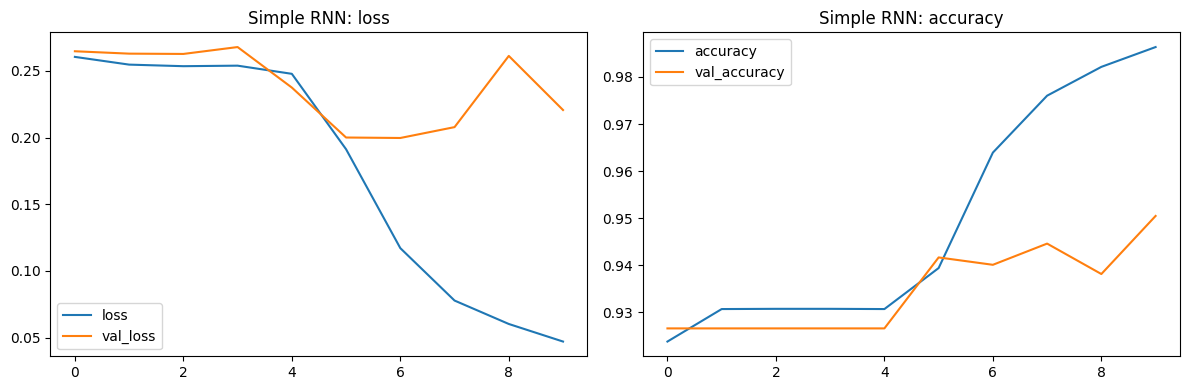

Simple RNN
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5937
           1       0.61      0.51      0.56       448

    accuracy                           0.94      6385
   macro avg       0.79      0.74      0.76      6385
weighted avg       0.94      0.94      0.94      6385



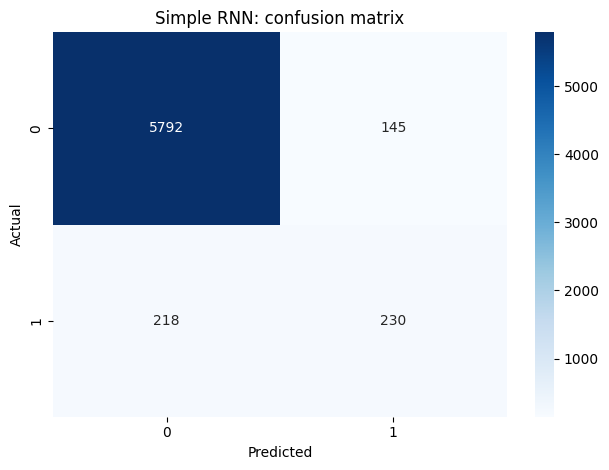

In [7]:
# Model 1: Simple RNN with trainable embedding.
rnn = keras.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation='relu'),
    output_layer(),
], name='simple_rnn')
compile_model(rnn)
rnn.summary()
t0 = time.time()
hist_rnn = rnn.fit(X_train_pad, y_train, validation_split=0.2, epochs=10, batch_size=32, callbacks=callbacks)
rnn_time = time.time() - t0
plot_history(hist_rnn, 'Simple RNN')
results = [evaluate(rnn, 'Simple RNN', rnn_time)]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.9501 - loss: 0.1692 - val_accuracy: 0.9565 - val_loss: 0.1485
Epoch 2/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9781 - loss: 0.0716 - val_accuracy: 0.9640 - val_loss: 0.1319
Epoch 3/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.9888 - loss: 0.0391 - val_accuracy: 0.9620 - val_loss: 0.1480
Epoch 4/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9930 - loss: 0.0255 - val_accuracy: 0.9589 - val_loss: 0.1801
Epoch 5/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.9949 - loss: 0.0182 - val_accuracy: 0.9573 - val_loss: 0.2049


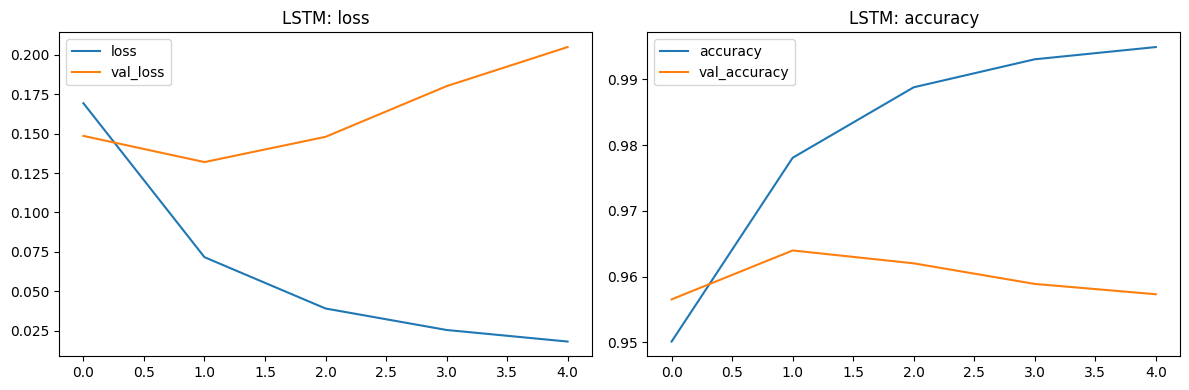

LSTM
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5937
           1       0.81      0.56      0.66       448

    accuracy                           0.96      6385
   macro avg       0.89      0.78      0.82      6385
weighted avg       0.96      0.96      0.96      6385



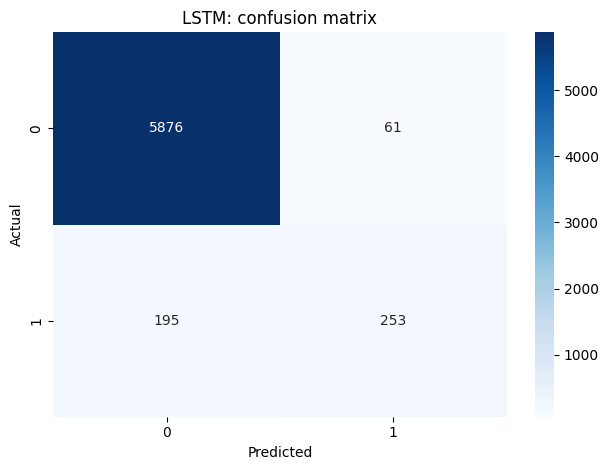

In [8]:
# Model 2: LSTM with trainable embedding.
lstm = keras.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation='relu'),
    output_layer(),
], name='lstm_trainable_embedding')
compile_model(lstm)
lstm.summary()
t0 = time.time()
hist_lstm = lstm.fit(X_train_pad, y_train, validation_split=0.2, epochs=10, batch_size=32, callbacks=callbacks)
lstm_time = time.time() - t0
plot_history(hist_lstm, 'LSTM')
results.append(evaluate(lstm, 'LSTM', lstm_time))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.5 MB/s eta 0:00:00
[==================================================] 100.0% 128.1/128.1MB downloaded


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_pretrained_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9370 - loss: 0.1890 - val_accuracy: 0.9368 - val_loss: 0.1915
Epoch 2/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9452 - loss: 0.1574 - val_accuracy: 0.9450 - val_loss: 0.1698
Epoch 3/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9494 - loss: 0.1435 - val_accuracy: 0.9466 - val_loss: 0.1629


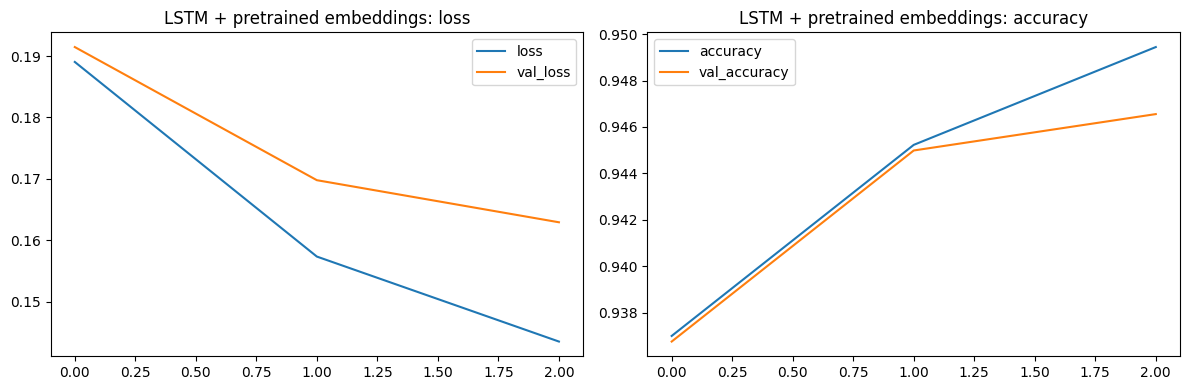

LSTM + pretrained embeddings
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5937
           1       0.72      0.25      0.37       448

    accuracy                           0.94      6385
   macro avg       0.84      0.62      0.67      6385
weighted avg       0.93      0.94      0.93      6385



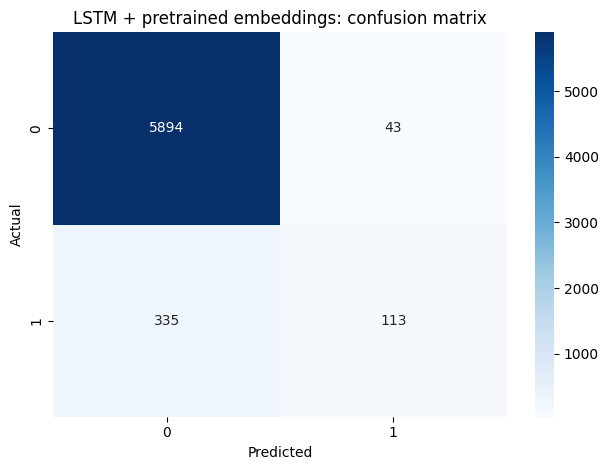

In [12]:
!pip install gensim

# Model 3: LSTM with pretrained GloVe/Word2Vec-style embeddings from gensim.
import gensim.downloader as api
embedding_model = api.load('glove-wiki-gigaword-100')
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

w2v_lstm = keras.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation='relu'),
    output_layer(),
], name='lstm_pretrained_embeddings')
compile_model(w2v_lstm)
w2v_lstm.summary()
t0 = time.time()
hist_w2v = w2v_lstm.fit(X_train_pad, y_train, validation_split=0.2, epochs=10, batch_size=32, callbacks=callbacks)
w2v_time = time.time() - t0
plot_history(hist_w2v, 'LSTM + pretrained embeddings')
results.append(evaluate(w2v_lstm, 'LSTM + pretrained embeddings', w2v_time))


In [13]:
# Compare models.
results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv('nlp_model_comparison.csv', index=False)

,model,accuracy,precision,recall,f1,training_time_seconds
0,Simple RNN,0.943148,0.939142,0.943148,0.940800,183.756822
1,LSTM,0.959906,0.956503,0.959906,0.956604,151.054266
2,LSTM + pretrained embeddings,0.940799,0.930653,0.940799,0.927199,48.124218


In [14]:
# Error analysis: show 2-3 incorrect predictions from the best model.
best_name = results_df.sort_values('f1', ascending=False).iloc[0]['model']
best_model = {'Simple RNN': rnn, 'LSTM': lstm, 'LSTM + pretrained embeddings': w2v_lstm}[best_name]
pred = predict_classes(best_model, X_test_pad)
true = true_classes(y_test)
errors = np.where(pred != true)[0][:3]
for idx in errors:
    original_index = X_test.index[idx]
    print('Text:', df.loc[original_index, TEXT_COLUMN])
    print('Clean:', df.loc[original_index, 'clean_text'])
    print('Actual:', label_encoder.classes_[true[idx]], 'Predicted:', label_encoder.classes_[pred[idx]])
    print('-' * 80)

Text: most tolerant nation in the world is india!   we tolerated #corruption #rapes #justice #blackmagic #blindfaith #scammers #criminals    
Clean: tolerant nation world india tolerated corruption rape justice blackmagic blindfaith scammer criminal
Actual: 0 Predicted: 1
--------------------------------------------------------------------------------
Text: @user you don't think w will share guarani aquifer water w those who humiliated little brother, @user 
Clean: think share guarani aquifer water humiliated little brother
Actual: 1 Predicted: 0
--------------------------------------------------------------------------------
Text: black judge quietly removed from #philandocastile shooting trial with little explanation  #newswithed 
Clean: black judge quietly removed philandocastile shooting trial little explanation newswithed
Actual: 1 Predicted: 0
--------------------------------------------------------------------------------


In [15]:
# Simple real-time prediction GUI with Gradio.
# !pip install gradio
import gradio as gr

def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred_id = predict_classes(best_model, pad)[0]
    return str(label_encoder.classes_[pred_id])

demo = gr.Interface(fn=predict_sentiment, inputs='text', outputs='text', title='Tweet Sentiment Classifier')
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://60d614e919ba99f428.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Report Notes

Use the generated comparison CSV, training curves, confusion matrices, classification reports, and error-analysis examples to complete the Part III report after adding the assigned tweet dataset.